In [42]:
import numpy as np
import joblib
import pandas as pd
from skimage import measure
from skimage.measure import shannon_entropy
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


IMG_SIZE = (512, 256)  # до какого размера были сжаты изображения

In [15]:
X = joblib.load('X_cropped_diff_images.joblib')
X_coords = joblib.load('X_coords_diff_images.joblib')
y = joblib.load('y_labels.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 398 изображений
Загружено 398 координат левого верхнегно угла
Загружено 398 лейблов


In [18]:
for i in range(10):
    print(f"Размерность {i} элемента {X[i].shape}")

Размерность 0 элемента (59, 115)
Размерность 1 элемента (60, 179)
Размерность 2 элемента (61, 423)
Размерность 3 элемента (24, 37)
Размерность 4 элемента (58, 115)
Размерность 5 элемента (41, 268)
Размерность 6 элемента (40, 300)
Размерность 7 элемента (38, 93)
Размерность 8 элемента (28, 64)
Размерность 9 элемента (77, 75)


In [26]:
def extract_features(diff_image, top_left):
    """
    Извлекает признаки из diff-области.
    
    Parameters:
        diff_image: обрезанное diff-изображение
        top_left: кортеж (y, x) координат относительно исходного скриншота
    """
    features = {}
    
    h, w = diff_image.shape
    
    # 1. Геометрические признаки (bounding box)
    features['width'] = w
    features['height'] = h
    features['area_bbox'] = w * h
    features['aspect_ratio'] = w / h if h > 0 else 0
    features['relative_area'] = (w * h) / (IMG_SIZE[0] * IMG_SIZE[1])
    
    # 2. Позиционные признаки
    features['top_left_y'] = top_left[0]
    features['top_left_x'] = top_left[1]
    features['center_y_norm'] = (top_left[0] + h/2) / IMG_SIZE[1]
    features['center_x_norm'] = (top_left[1] + w/2) / IMG_SIZE[0]
    
    # 3. Признаки интенсивности
    features['mean_intensity'] = np.mean(diff_image)
    features['std_intensity'] = np.std(diff_image)
    features['max_intensity'] = np.max(diff_image)
    features['sum_intensity'] = np.sum(diff_image)
    features['nonzero_ratio'] = np.count_nonzero(diff_image) / diff_image.size
    
    # 4. Морфологические признаки (связные компоненты)
    binary = (diff_image > 0.01).astype(np.uint8)
    labeled = measure.label(binary, connectivity=2)
    regions = measure.regionprops(labeled)
    
    features['num_components'] = len(regions)
    
    if len(regions) > 0:
        areas = [r.area for r in regions]
        features['largest_component_area'] = max(areas)
        features['largest_component_ratio'] = max(areas) / (np.count_nonzero(binary) + 1)
        features['mean_component_area'] = np.mean(areas)
        features['std_component_area'] = np.std(areas) if len(areas) > 1 else 0
        
        # Характеристики крупнейшей компоненты
        largest_region = max(regions, key=lambda r: r.area)
        features['largest_compactness'] = (largest_region.perimeter ** 2) / (4 * np.pi * largest_region.area + 1)
        features['largest_eccentricity'] = largest_region.eccentricity
        features['largest_solidity'] = largest_region.solidity  # area / convex_area
        features['largest_extent'] = largest_region.extent  # area / bbox_area
        features['largest_orientation'] = largest_region.orientation
    else:
        features['largest_component_area'] = 0
        features['largest_component_ratio'] = 0
        features['mean_component_area'] = 0
        features['std_component_area'] = 0
        features['largest_compactness'] = 0
        features['largest_eccentricity'] = 0
        features['largest_solidity'] = 0
        features['largest_extent'] = 0
        features['largest_orientation'] = 0
    
    # 5. Текстурные признаки
    # Приводим к одному размеру для текстурного анализа
    resized = resize(diff_image, (32, 32), anti_aliasing=True)
    
    features['entropy'] = shannon_entropy(resized + 1e-10)
    
    # Статистики проекций
    row_proj = np.sum(resized, axis=1)
    col_proj = np.sum(resized, axis=0)
    features['std_row_projection'] = np.std(row_proj)
    features['std_col_projection'] = np.std(col_proj)
    features['max_row_projection'] = np.max(row_proj)
    features['max_col_projection'] = np.max(col_proj)
    
    return features


def create_feature_dataset(X_diff, X_coords):
    """
    Создает датафрейм с признаками для всех образцов.
    
    Parameters:
        X_diff: список обрезанных diff-изображений
        X_coords: список кортежей (y, x) верхнего левого угла
    """
    all_features = []
    
    for i, (diff_img, coords) in enumerate(zip(X_diff, X_coords)):
        features = extract_features(diff_img, coords)
        features['sample_id'] = i
        all_features.append(features)
    
    df = pd.DataFrame(all_features)
    return df

In [27]:
df_features = create_feature_dataset(X, X_coords)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")
print("\nПервые 5 строк:")
print(df_features.head())
print("\nСтатистика по признакам:")
print(df_features.describe())

Размер датафрейма: (398, 30)
Количество признаков: 29

Первые 5 строк:
   width  height  area_bbox  aspect_ratio  relative_area  top_left_y  \
0    115      59       6785      1.949153       0.051765          33   
1    179      60      10740      2.983333       0.081940         162   
2    423      61      25803      6.934426       0.196861          99   
3     37      24        888      1.541667       0.006775         128   
4    115      58       6670      1.982759       0.050888          34   

   top_left_x  center_y_norm  center_x_norm  mean_intensity  ...  \
0         259       0.244141       0.618164        0.006381  ...   
1          53       0.750000       0.278320        0.075124  ...   
2          40       0.505859       0.491211        0.039315  ...   
3          46       0.546875       0.125977        0.032883  ...   
4         259       0.246094       0.618164        0.006447  ...   

   largest_eccentricity  largest_solidity  largest_extent  \
0              0.470199   

In [52]:
# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 100:
        subtype_labels.append('disappeared')
    elif i < 150:
        subtype_labels.append('color_change')
    elif i < 200:
        subtype_labels.append('shift')
    elif i < 300:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

# Проверяем распределение
print("Распределение подтипов в train:")
print(pd.Series(sub_train).value_counts(normalize=True))
print("\nРаспределение подтипов в test:")
print(pd.Series(sub_test).value_counts(normalize=True))

Распределение подтипов в train:
disappeared     0.251799
dynamic         0.251799
banner          0.244604
color_change    0.125899
shift           0.125899
Name: proportion, dtype: float64

Распределение подтипов в test:
banner          0.250
disappeared     0.250
dynamic         0.250
color_change    0.125
shift           0.125
Name: proportion, dtype: float64


### Предварительные выводы
Подготовка данных почти завершена. Не делали нормализацию, так как для деревьев она не играет роли. Сначала посмотрим как они справятся.

In [55]:
rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97        60
           1       0.97      0.98      0.98        60

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120


Топ-10 важных признаков:
                   feature  importance
4            relative_area    0.168068
1                   height    0.114329
2                area_bbox    0.111024
18      std_component_area    0.080326
12           sum_intensity    0.078896
11           max_intensity    0.067726
0                    width    0.054544
15  largest_component_area    0.033148
8            center_x_norm    0.032370
24                 entropy    0.029890


In [56]:
# Детальный отчёт по подтипам
for subtype in np.unique(sub_test):
    mask = (sub_test == subtype)
    print(f"\n=== {subtype} ===")
    print(classification_report(y_test[mask], y_pred[mask]))


=== banner ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.00      0.00      0.00         0

    accuracy                           0.93        30
   macro avg       0.50      0.47      0.48        30
weighted avg       1.00      0.93      0.97        30


=== color_change ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15


=== disappeared ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        30

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


=== dynamic ===
              precision    recall  f1-score   suppo

/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12

Индексы с ошибками [339 197 390]


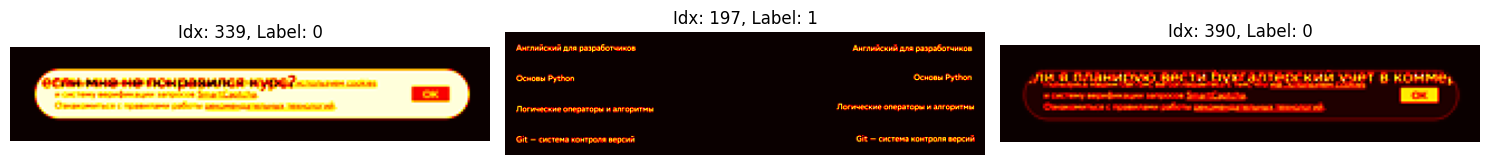

In [58]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[incorrect_mask]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

### Выводы
disappeared, color_change, dynamic — идеальная классификация (F1=1.0). Модель безошибочно распознаёт пропажу элементов, изменение цвета и динамические элементы. Это говорит о том, что выбранные признаки отлично описывают эти явления.

339 и 390 banner — recall 0.93 для класса 0 (2 ложных срабатывания из 30). Модель ошибочно приняла 2 баннера за баги. Возможно, из-за того что баннеры очень крупные и контрастные, то стали похожи на значимое изменение. Не критично, учитывая, что баг не пропущен, а размер тестовой выборки очень мал.

197 shift (сдвиг элемента) — recall 0.93 для класса 1 (1 пропущенный баг из 15). Это пропущенный дефект! Это плохо! Отзеркалил значения на том же уровне.

Попробуем сделать анализ зеркальных элементов, то есть разделение diff по середине по оси Y и по оси X и проверку совпадают ли эти части. Если да, то это однозначно баг сдвига.

In [83]:
def compute_symmetry_score(diff_images):
    """
    Делит diff-область пополам по вертикали и горизонтали,
    сравнивает половинки через среднюю абсолютную разницу.
    Возвращает минимальную разницу (0 = полная симметрия).
    """
    symmetry_score = []

    for diff_image in diff_images:
        h, w = diff_image.shape
        
        # --- Вертикальное деление (левая/правая половина) ---
        mid_w = w // 2
        left = diff_image[:, :mid_w]
        # Используем все столбцы справа и обрезаем до размера left
        right = diff_image[:, w-mid_w:]  # Берем последние mid_w столбцов
        
        if left.size > 0 and right.size > 0 and left.shape == right.shape:
            vert_diff = np.mean(np.abs(left - right))
        else:
            vert_diff = np.inf
        
        # --- Горизонтальное деление (верх/низ) ---
        mid_h = h // 2
        top = diff_image[:mid_h, :]
        bottom = diff_image[h-mid_h:, :]  # Берем последние mid_h строк
        
        if top.size > 0 and bottom.size > 0 and top.shape == bottom.shape:
            horiz_diff = np.mean(np.abs(top - bottom))
        else:
            horiz_diff = np.inf

        symmetry_score.append(min(vert_diff, horiz_diff))
    
    return symmetry_score

In [77]:
X = joblib.load('X_cropped_diff_images.joblib')
X_coords = joblib.load('X_coords_diff_images.joblib')
y = joblib.load('y_labels.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 398 изображений
Загружено 398 координат левого верхнегно угла
Загружено 398 лейблов


In [79]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")
print("\nПервые 5 строк:")
print(df_features.head())
print("\nСтатистика по признакам:")
print(df_features.describe())

Размер датафрейма: (398, 31)
Количество признаков: 30

Первые 5 строк:
   width  height  area_bbox  aspect_ratio  relative_area  top_left_y  \
0    115      59       6785      1.949153       0.051765          33   
1    179      60      10740      2.983333       0.081940         162   
2    423      61      25803      6.934426       0.196861          99   
3     37      24        888      1.541667       0.006775         128   
4    115      58       6670      1.982759       0.050888          34   

   top_left_x  center_y_norm  center_x_norm  mean_intensity  ...  \
0         259       0.244141       0.618164        0.006381  ...   
1          53       0.750000       0.278320        0.075124  ...   
2          40       0.505859       0.491211        0.039315  ...   
3          46       0.546875       0.125977        0.032883  ...   
4         259       0.246094       0.618164        0.006447  ...   

   largest_solidity  largest_extent  largest_orientation   entropy  \
0          0.6718

In [80]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        60
           1       0.97      1.00      0.98        60

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120


Топ-10 важных признаков:
                   feature  importance
1                   height    0.122654
2                area_bbox    0.120243
4            relative_area    0.117132
12           sum_intensity    0.105816
11           max_intensity    0.082789
0                    width    0.054419
15  largest_component_area    0.042526
24                 entropy    0.033091
18      std_component_area    0.031957
7            center_y_norm    0.029948


In [81]:
# Детальный отчёт по подтипам
for subtype in np.unique(sub_test):
    mask = (sub_test == subtype)
    print(f"\n=== {subtype} ===")
    print(classification_report(y_test[mask], y_pred[mask]))


=== banner ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.00      0.00      0.00         0

    accuracy                           0.93        30
   macro avg       0.50      0.47      0.48        30
weighted avg       1.00      0.93      0.97        30


=== color_change ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15


=== disappeared ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        30

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


=== dynamic ===
              precision    recall  f1-score   suppo

/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Индексы с ошибками [339 197 390]


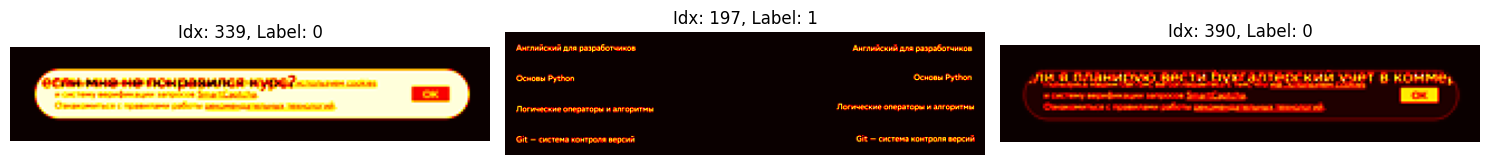

In [82]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[incorrect_mask]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

### Выводы
Симметрия не помогла исключить баг. Данный признак и в том не попал, но оставим его для кучи, а то и так их не много. Попробуем повторяющиеся паттерны.

In [88]:
def detect_duplicated_pattern(diff_images):
    """
    Ищет повторяющиеся вертикальные паттерны в diff-изображении.
    Возвращает score (0 = идеальное повторение, т.е. явный сдвиг)
    """
    duplicate_pattern_best_score = []
    duplicate_pattern_best_shift = []
    for diff_image in diff_images:
        h, w = diff_image.shape
        
        if h < 10 or w < 10:
            return 1.0
        
        best_score = 1.0
        best_shift = 0
        
        # Ищем повторяющиеся колонки/блоки
        # Пробуем разные сдвиги (половина ширины и другие)
        for shift_ratio in [0.5, 0.33, 0.25]:  # Проверяем разные соотношения
            shift = int(w * shift_ratio)
            if shift < 10:
                continue
                
            # Сравниваем левую часть с правой (со сдвигом)
            for start in range(0, w - shift, max(1, shift // 4)):
                left_block = diff_image[:, start:start + shift]
                right_block = diff_image[:, start + shift:start + 2*shift]
                
                if right_block.shape[1] >= shift * 0.8:
                    # Обрезаем до одинакового размера
                    min_w = min(left_block.shape[1], right_block.shape[1])
                    if min_w > 5:
                        # Нормализуем
                        left_norm = left_block[:, :min_w].astype(float)
                        right_norm = right_block[:, :min_w].astype(float)
                        
                        if left_norm.max() > 0:
                            left_norm /= left_norm.max()
                        if right_norm.max() > 0:
                            right_norm /= right_norm.max()
                        
                        similarity = np.mean(np.abs(left_norm - right_norm))
                        
                        if similarity < best_score:
                            best_score = similarity
                            best_shift = shift
        
        duplicate_pattern_best_score.append(best_score)
        duplicate_pattern_best_shift.append(best_shift)
    return duplicate_pattern_best_score, duplicate_pattern_best_shift

In [86]:
X = joblib.load('X_cropped_diff_images.joblib')
X_coords = joblib.load('X_coords_diff_images.joblib')
y = joblib.load('y_labels.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 398 изображений
Загружено 398 координат левого верхнегно угла
Загружено 398 лейблов


In [89]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")
print("\nПервые 5 строк:")
print(df_features.head())
print("\nСтатистика по признакам:")
print(df_features.describe())

Размер датафрейма: (398, 33)
Количество признаков: 32

Первые 5 строк:
   width  height  area_bbox  aspect_ratio  relative_area  top_left_y  \
0    115      59       6785      1.949153       0.051765          33   
1    179      60      10740      2.983333       0.081940         162   
2    423      61      25803      6.934426       0.196861          99   
3     37      24        888      1.541667       0.006775         128   
4    115      58       6670      1.982759       0.050888          34   

   top_left_x  center_y_norm  center_x_norm  mean_intensity  ...  \
0         259       0.244141       0.618164        0.006381  ...   
1          53       0.750000       0.278320        0.075124  ...   
2          40       0.505859       0.491211        0.039315  ...   
3          46       0.546875       0.125977        0.032883  ...   
4         259       0.246094       0.618164        0.006447  ...   

   largest_orientation   entropy  std_row_projection  std_col_projection  \
0        -2

In [90]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        60
           1       0.97      1.00      0.98        60

    accuracy                           0.98       120
   macro avg       0.98      0.98      0.98       120
weighted avg       0.98      0.98      0.98       120


Топ-10 важных признаков:
                   feature  importance
1                   height    0.130891
4            relative_area    0.128476
2                area_bbox    0.110512
12           sum_intensity    0.086670
18      std_component_area    0.064915
11           max_intensity    0.064266
0                    width    0.060728
15  largest_component_area    0.043523
7            center_y_norm    0.032752
8            center_x_norm    0.024687


In [91]:
# Детальный отчёт по подтипам
for subtype in np.unique(sub_test):
    mask = (sub_test == subtype)
    print(f"\n=== {subtype} ===")
    print(classification_report(y_test[mask], y_pred[mask]))


=== banner ===
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        30
           1       0.00      0.00      0.00         0

    accuracy                           0.93        30
   macro avg       0.50      0.47      0.48        30
weighted avg       1.00      0.93      0.97        30


=== color_change ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15


=== disappeared ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        30

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


=== dynamic ===
              precision    recall  f1-score   suppo

/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Индексы с ошибками [339 197 390]


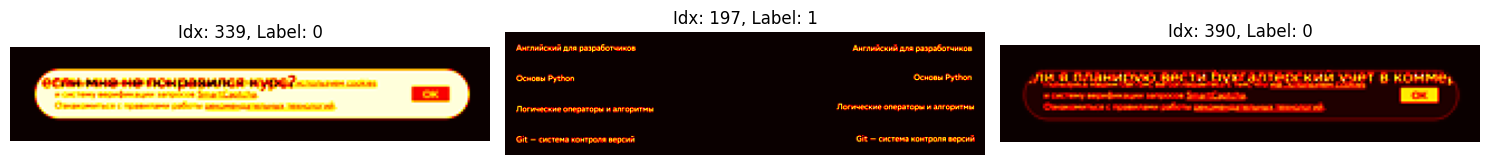

In [92]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[incorrect_mask]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

 ### Выводы 
 Добавлением признаков не получается решить пропуск 1 дефекта.
 Так как мы получили очень хорошую оценку сразу, но явно нам не хватает признака, который бы однозначно определял что 197 diff это баг. Конечно можно увеличить количество данных для обучения. Но и дефект является синтетическим. Так что думаю, что на этом можно остановиться для классических моделей.
 Пробовать другие классические модели на таком скромном дата сете смысла не имеет. Но вот очень интересно как с этим справятся нейронные сети! 